In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

In [2]:
student = pd.read_csv("data/Student_Performance.csv")


print("Student Data Sample:")
student.head()

Student Data Sample:


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,optional_i_score,optional_ii__score,optional_iii__score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [3]:
student.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  optional_i_score       25000 non-null  float64
 12  optional_ii__score     25000 non-null  float64
 13  optional_iii__score    25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [4]:
student.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'optional_i_score',
       'optional_ii__score', 'optional_iii__score', 'overall_score',
       'final_grade'],
      dtype='object')

In [5]:
student = student.drop_duplicates()
student.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15000 non-null  int64  
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   school_type            15000 non-null  object 
 4   parent_education       15000 non-null  object 
 5   study_hours            15000 non-null  float64
 6   attendance_percentage  15000 non-null  float64
 7   internet_access        15000 non-null  object 
 8   travel_time            15000 non-null  object 
 9   extra_activities       15000 non-null  object 
 10  study_method           15000 non-null  object 
 11  optional_i_score       15000 non-null  float64
 12  optional_ii__score     15000 non-null  float64
 13  optional_iii__score    15000 non-null  float64
 14  overall_score          15000 non-null  float64
 15  final_g

In [6]:
student.isnull().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
optional_i_score         0
optional_ii__score       0
optional_iii__score      0
overall_score            0
final_grade              0
dtype: int64

In [7]:
def remove_outliers(student, column):
    student = student.copy()
    Q1 = student[column].quantile(0.25)
    Q3 = student[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    student[column] = np.clip(student[column], lower_bound, upper_bound)
    return student

student.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15000 non-null  int64  
 1   age                    15000 non-null  int64  
 2   gender                 15000 non-null  object 
 3   school_type            15000 non-null  object 
 4   parent_education       15000 non-null  object 
 5   study_hours            15000 non-null  float64
 6   attendance_percentage  15000 non-null  float64
 7   internet_access        15000 non-null  object 
 8   travel_time            15000 non-null  object 
 9   extra_activities       15000 non-null  object 
 10  study_method           15000 non-null  object 
 11  optional_i_score       15000 non-null  float64
 12  optional_ii__score     15000 non-null  float64
 13  optional_iii__score    15000 non-null  float64
 14  overall_score          15000 non-null  float64
 15  final_g

In [8]:
student.parent_education.unique()
student.parent_education.value_counts()

parent_education
diploma          2581
post graduate    2535
high school      2532
graduate         2481
no formal        2445
phd              2426
Name: count, dtype: int64

In [9]:
student['parent_education'] = student['parent_education'].replace('diploma', 1, regex=True)
student['parent_education'] = student['parent_education'].replace('post graduate', 2, regex=True)
student['parent_education'] = student['parent_education'].replace('high school', 3, regex=True)
student['parent_education'] = student['parent_education'].replace('graduate', 4, regex=True)
student['parent_education'] = student['parent_education'].replace('no formal', 5, regex=True)
student['parent_education'] = student['parent_education'].replace('phd', 6, regex=True)
student.head()

C:\Users\Raunak\AppData\Local\Temp\ipykernel_10736\629997971.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  student['parent_education'] = student['parent_education'].replace('phd', 6, regex=True)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,optional_i_score,optional_ii__score,optional_iii__score,overall_score,final_grade
0,1,14,male,public,2,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,4,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,2,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,3,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,3,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [10]:
student.final_grade.unique()
student.final_grade.value_counts()

final_grade
d    3770
c    3697
e    3378
f    1796
b    1638
a     721
Name: count, dtype: int64

In [11]:
student['final_grade'] = student['final_grade'].replace('a', 1, regex=True)
student['final_grade'] = student['final_grade'].replace('b', 2, regex=True)
student['final_grade'] = student['final_grade'].replace('c', 3, regex=True)
student['final_grade'] = student['final_grade'].replace('d', 4, regex=True)
student['final_grade'] = student['final_grade'].replace('e', 5, regex=True)
student['final_grade'] = student['final_grade'].replace('f', 6, regex=True)
student.head()

C:\Users\Raunak\AppData\Local\Temp\ipykernel_10736\1339398232.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  student['final_grade'] = student['final_grade'].replace('f', 6, regex=True)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,optional_i_score,optional_ii__score,optional_iii__score,overall_score,final_grade
0,1,14,male,public,2,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,5
1,2,18,female,public,4,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,4
2,3,17,female,private,2,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,2
3,4,16,other,public,3,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,5
4,5,16,female,public,3,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,6


In [12]:
X_selected = student[["attendance_percentage", "optional_i_score", "optional_ii__score", "optional_iii__score",
"overall_score", "parent_education"]]
Y = student["final_grade"]
print(X_selected.head())
print(Y.head())

   attendance_percentage  optional_i_score  optional_ii__score  \
0                   84.3              42.7                55.4   
1                   87.8              57.6                68.8   
2                   65.5              84.8                95.0   
3                   58.1              44.4                27.5   
4                   61.0               8.9                32.7   

   optional_iii__score  overall_score  parent_education  
0                 57.0           53.1                 2  
1                 64.8           61.3                 4  
2                 79.2           89.6                 2  
3                 54.7           41.6                 3  
4                 30.0           25.4                 3  
0    5
1    4
2    2
3    5
4    6
Name: final_grade, dtype: int64


In [13]:
class StandardScalers:
    def __init__(self):
        self.mean = None
        self.std  = None

    def fit(self, X):
        """Learn mean and std from training data"""
        self.mean = np.mean(X, axis=0)   # mean of each column
        self.std  = np.std(X, axis=0)    # std of each column
        return self

    def transform(self, X):
        """Apply scaling using learned mean and std"""
        return (X - self.mean) / (self.std + 1e-8)   # +1e-8 avoids divide by zero

    def fit_transform(self, X):
        """Fit and transform in one step"""
        self.fit(X)
        return self.transform(X)

        

Train size: (10500, 6), Test size: (4500, 6)
Epoch 100/1000  |  Loss: 1.0576
Epoch 200/1000  |  Loss: 0.9302
Epoch 300/1000  |  Loss: 0.8582
Epoch 400/1000  |  Loss: 0.8088
Epoch 500/1000  |  Loss: 0.7717
Epoch 600/1000  |  Loss: 0.7422
Epoch 700/1000  |  Loss: 0.7180
Epoch 800/1000  |  Loss: 0.6974
Epoch 900/1000  |  Loss: 0.6796
Epoch 1000/1000  |  Loss: 0.6641

  Train Accuracy : 77.07%
  Test  Accuracy : 76.36%


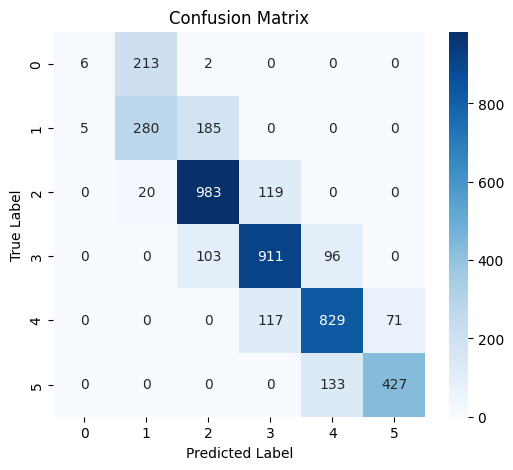


Classification Report (Test Set):
              precision    recall  f1-score   support

           A       0.55      0.03      0.05       221
           B       0.55      0.60      0.57       470
           C       0.77      0.88      0.82      1122
           D       0.79      0.82      0.81      1110
           E       0.78      0.82      0.80      1017
           F       0.86      0.76      0.81       560

    accuracy                           0.76      4500
   macro avg       0.72      0.65      0.64      4500
weighted avg       0.76      0.76      0.75      4500


Confusion Matrix (Test Set):
   A    B    C    D    E    F
A  6  213    2    0    0    0
B  5  280  185    0    0    0
C  0   20  983  119    0    0
D  0    0  103  911   96    0
E  0    0    0  117  829   71
F  0    0    0    0  133  427


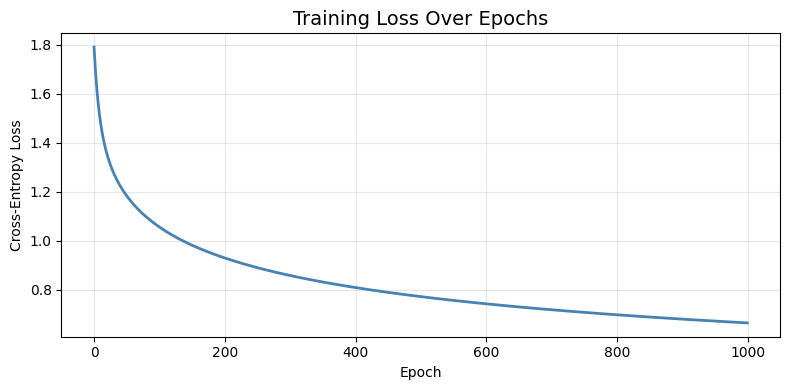

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ─── 1. TRAIN / TEST SPLIT ───────────────────────────────────────────────────
X = X_selected.values.astype(float)
Y_raw = Y.values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y_raw, test_size=0.30, random_state=42
)

# Scale features (important for gradient descent)
scaler = StandardScalers()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# ─── 2. HELPER FUNCTIONS ─────────────────────────────────────────────────────


def softmax(Z):
    """Numerically stable softmax."""
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)




def one_hot_encode(y, num_classes):
    """Convert label vector to one-hot matrix."""
    n = len(y)
    one_hot = np.zeros((n, num_classes))
    # labels are 1-indexed (1 to 6), shift to 0-indexed
    one_hot[np.arange(n), y - 1] = 1
    return one_hot

def compute_loss(y_onehot, probs):
    """Cross-entropy loss."""
    n = y_onehot.shape[0]
    log_probs = np.log(probs + 1e-9)          # clip to avoid log(0)
    return -np.sum(y_onehot * log_probs) / n

def predict(X, W, b):
    # Forward pass → class labels (1-indexed).
    Z     = X @ W + b
    probs = softmax(Z)
    return np.argmax(probs, axis=1) + 1        # shift back to 1-indexed

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# ─── 3. LOGISTIC REGRESSION FROM SCRATCH (Softmax / Multinomial) ─────────────
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.1, epochs=1000, num_classes=6):
        self.lr          = learning_rate
        self.epochs      = epochs
        self.num_classes = num_classes
        self.W           = None
        self.b           = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights & bias
        np.random.seed(42)
        self.W = np.random.randn(n_features, self.num_classes) * 0.01
        self.b = np.zeros((1, self.num_classes))
        y_onehot = one_hot_encode(y, self.num_classes)
        for epoch in range(self.epochs):
            # ── Forward pass ──────────────────────────────────
            Z     = X @ self.W + self.b          # (n, num_classes)
            probs = softmax(Z)                   # (n, num_classes)
            # ── Loss ──────────────────────────────────────────
            loss = compute_loss(y_onehot, probs)
            self.loss_history.append(loss)
            # ── Backward pass (gradients) ──────────────────────
            dZ  = (probs - y_onehot) / n_samples  # (n, num_classes)
            dW  = X.T @ dZ                         # (n_features, num_classes)
            db  = np.sum(dZ, axis=0, keepdims=True)
            # ── Parameter update ──────────────────────────────
            self.W -= self.lr * dW
            self.b -= self.lr * db
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{self.epochs}  |  Loss: {loss:.4f}")

        return self

    def predict(self, X):
        return predict(X, self.W, self.b)

# ─── 4. TRAIN ─────────────────────────────────────────────────────────────────


model = LogisticRegressionScratch(learning_rate=0.1, epochs=1000, num_classes=6)
model.fit(X_train, y_train)

# ─── 5. EVALUATE ──────────────────────────────────────────────────────────────
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

train_acc = accuracy(y_train, y_train_pred)
test_acc  = accuracy(y_test,  y_test_pred)

print(f"\n{'='*40}")
print(f"  Train Accuracy : {train_acc * 100:.2f}%")
print(f"  Test  Accuracy : {test_acc  * 100:.2f}%")
print(f"{'='*40}")


# ─── 6. CONFUSION MATRIX ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
# ─── 6. DETAILED METRICS ──────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix

grade_labels = ['A', 'B', 'C', 'D', 'E', 'F']

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=grade_labels))

print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, index=grade_labels, columns=grade_labels)
print(cm_df)

# # ─── 7. PLOT LOSS CURVE ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='steelblue', linewidth=2)
plt.title("Training Loss Over Epochs", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()